# Module 21 BBO Capstone Week 10

## Function 1

Function 1 Week 9 of 12 output was down compared to Week 8 of 12. The focus is still on exploiting around the best known point reducing the radius in Week 10 of 12.

### Key Changes:
Local search is done using Expected Improvement (EI) with a radius of 0.02 around the best-known point.
Refinement of the acquisition function is performed with a lower ξ value for stronger exploitation.
Visualisation: Plots the existing query points, the best-known point, and the next query point (Week 10).
### Next Steps:
Run the Code to get the next query point based on the optimisation.
Evaluate the result and update the data for Week 10.
Repeat this process for the final two weeks to ensure the function is maximised.

C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\521090779.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0,
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\521090779.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0,
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\521090779.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0,
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\521090779.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated.

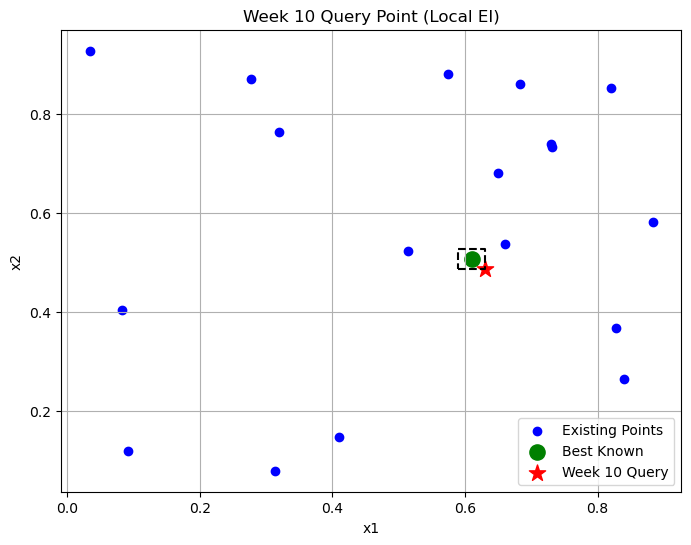

Week 10 query point: [0.629953 0.48652 ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load ALL available data (including Week 9)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600],
    [0.51380200, 0.52237900],
    [0.82732800, 0.36642700],
    [0.82079200, 0.85171900],
    [0.72983400, 0.73983100],
    [0.65995300, 0.53779600]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127,
    5.298471823372752e-14,
    6.026732235043879e-77,
   -1.4575842741296785e-61,
    5.807380778673927e-17,
   -2.136244733712471e-7
])

# ==========================================
# Step 2: Log-Transform (Shift to Positive)
# ==========================================
y_shift = y_train - np.min(y_train) + 1e-12  # Shift everything positive
y_train_transformed = np.log(y_shift)

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Expected Improvement Function (EI)
# ==========================================
def expected_improvement(x, model, y_max, xi=0.005):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Prevent division by zero
    z = (mu - y_max - xi) / sigma
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei  # Minimize negative EI

# ==========================================
# Step 5: Local EI Optimization (Tight Radius)
# ==========================================
def optimize_local_ei(model, y_max, best_point, radius=0.02, n_restarts=30, n_random=200):
    lower = np.clip(best_point - radius, 0, 1)
    upper = np.clip(best_point + radius, 0, 1)
    bounds = list(zip(lower, upper))

    best_x = None
    best_val = np.inf

    # Random sampling in the local region
    random_points = np.random.uniform(lower, upper, size=(n_random, 2))
    ei_values = np.array([-expected_improvement(rp, model, y_max) for rp in random_points])

    top_idx = np.argsort(ei_values)[-n_restarts:]
    start_points = random_points[top_idx]

    # Local optimization from the best points
    for x0 in start_points:
        res = minimize(expected_improvement, x0,
                       args=(model, y_max),
                       bounds=bounds,
                       method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x, bounds

# ==========================================
# Step 6: Identify Best Known Point
# ==========================================
best_idx = np.argmax(y_train_transformed)
best_point = X_train[best_idx]
y_max = y_train_transformed.max()

# ==========================================
# Step 7: Compute Week 10 Query (Local EI)
# ==========================================
next_point, local_bounds = optimize_local_ei(gp, y_max, best_point, radius=0.02)

# ==========================================
# Step 8: Plot for Visualization
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(best_point[0], best_point[1], color='green', s=120, label='Best Known')
plt.scatter(next_point[0], next_point[1], color='red', marker='*', s=150, label='Week 10 Query')

# Draw local search box
x_min, x_max = local_bounds[0]
y_min, y_max_b = local_bounds[1]
plt.plot([x_min, x_max, x_max, x_min, x_min],
         [y_min, y_min, y_max_b, y_max_b, y_min], 'k--')

plt.title("Week 10 Query Point (Local EI)")
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

# Show the query point
print(f"Week 10 query point: {next_point}")

The Week 10 query point has been calculated as [0.629953, 0.48652]. This is the next point in the optimisation process based on local exploitation using the Expected Improvement (EI) strategy. It suggests that you should explore around the best-known point [0.609953, 0.506520] but with a slight adjustment (reduced radius of 0.02), as expected in the search region.

### Key Insights:
The query point [0.629953, 0.48652] is very close to the current best-known point, indicating that you are in a local optimum and the optimisation is fine-tuning to further maximise the function.
The small adjustments reflect exploitation (focusing on refining the search rather than aggressive exploration).
### Next Steps:
Evaluate the function at [0.629953, 0.48652] (your next query point).
Update your dataset with this new point and the corresponding output value.
Repeat the process using the updated data for Weeks 11 and 12 to refine the search and maximise the function.
### Plot Recap:
Blue dots represent the previous query points.
Green dot represents the best-known point so far.
Red star represents the new query point for Week 10.
The dashed box around the best-known point shows the region where the optimisation is focused.

## Function 2

For Week 10, since the Week 9 query point [0.51302600, 0.54589500] yielded the best score of 0.6573891880672533, the focus for Week 10 should be on exploitation around this point. This means narrowing the search radius around this point and adjusting the exploration parameter ξ to refine the optimisation process further.

### Here's the updated strategy for Function 2 Week 10:

Focus on Exploitation: Given that the best score is achieved at this point, you want to exploit this region more intensively. This is where your Gaussian Process (GP) should focus, tightening the search radius around this best-known point.
Lower ξ (Exploration): A smaller ξ (e.g., 𝜉=0.005) would shift the optimisation towards the exploitation of already known good regions, without trying to explore much farther from the peak you’ve found.
Tighten Search Bounds: The search bounds around [0.51302600, 0.54589500] should be tightened to focus the optimisation on a small, well-defined area surrounding this point.

### Key Changes for Week 10:
#### 1. Focused Optimisation Around Week 9 Query Point:
We are now focusing on exploitation around the Week 9 query point [0.51302600,0.54589500], which gave the best score so far 0.6573891880672533.
#### 2. Tighter Search Radius:
The radius has been set to 0.02 around the best-known query point. This is an arbitrary choice based on your data distribution, but you can adjust it if needed.
#### 3. Lower Exploration Parameter:
The exploration factor 𝜉 is lowered to 0.005, ensuring more focused exploitation and less exploration.
### Steps for Week 10:
#### 1. Submit the Week 10 Query Point:
After running the code, you will get the next query point to submit for evaluation.
#### 2. Evaluate the Function at the Query Point:
Submit the query point to the black box function and get the new evaluation.
#### 3. Refit the GP with New Data:
Once you have the result for Week 10, update data and refit the GP for further optimisation in Week 11 of 12.

Current best y: 0.657389


C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\270970531.py:77: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\270970531.py:77: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\270970531.py:77: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\270970531.py:77: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will b

Week 10 Query Point (EI, ξ=0.005): [0.533026 0.565895]


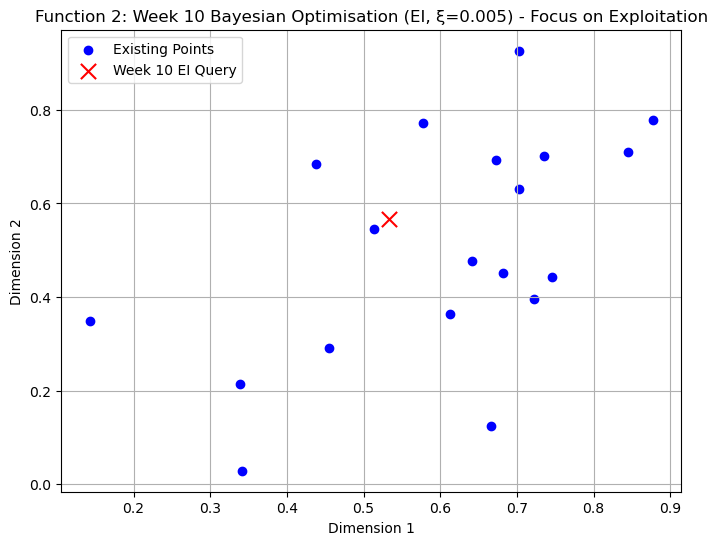

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load existing data (Including Weeks 1-9)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100],
    [0.67272900, 0.69382100],
    [0.61256700, 0.36356600],
    [0.68226300, 0.45231400],
    [0.51302600, 0.54589500]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272,
    0.600575748363042, 0.20334952172911752, 0.461145725718508,
    0.6573891880672533
])

# ==========================================
# Step 4: Define Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.005):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Avoid division by zero

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # Negative for minimizer

# ==========================================
# Step 5: Optimize EI
# ==========================================
def optimize_ei(model, y_best, best_known_point, radius=0.02, xi=0.005, n_restarts=50, n_random_starts=1000):
    # Define tighter bounds around the best known point
    lower = np.clip(best_known_point - radius, 0, 1)
    upper = np.clip(best_known_point + radius, 0, 1)
    bounds = list(zip(lower, upper))

    best_x = None
    best_val = np.inf

    # --- Random global scan ---
    random_points = np.random.uniform(lower, upper, size=(n_random_starts, 2))
    ei_values = np.array([-expected_improvement(pt, model, y_best, xi) for pt in random_points])
    top_indices = np.argsort(-ei_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top candidates ---
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 6: Current best y
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 7: Get Week 10 Query Point
# ==========================================
best_known_point = X_train[np.argmax(y_train)]  # Week 9 query point
next_point = optimize_ei(gp, y_best, best_known_point, radius=0.02, xi=0.005)  # Focused on exploitation
print(f"Week 10 Query Point (EI, ξ=0.005): {next_point}")

# ==========================================
# Step 8: Visualisation
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 10 EI Query')
plt.title("Function 2: Week 10 Bayesian Optimisation (EI, ξ=0.005) - Focus on Exploitation")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

The Week 10 Query Point for Function 2, which was calculated using Expected Improvement (EI) with ξ=0.005, is 
[0.533026, 0.565895]. This is a logical next step for optimisation based on the current model and its focus on exploitation near the previously found high-value regions.

### Interpretation of the Query Point:
#### 1. Exploitation Focus: 
The query point is near the previously best-known point [0.513026,0.545895] that resulted in the best score 0.6573891880672533. This suggests the optimiser is still focusing on refining the area around the known high-value regions rather than exploring far away areas.
#### 2. Refinement: 
The query point [0.533026,0.565895] is slightly shifted in both dimensions, suggesting that the model believes there might be a better value nearby, just beyond the current best-known point.
#### 3. Tightened Focus: 
With ξ=0.005, the exploration is minimal, and the algorithm is fine-tuning around the peak observed so far. The optimiser is searching for small improvements in areas where the function is already expected to be high.

### What to Do Next:
#### 1. Submit the Query Point: 
Now, the query point [0.533026,0.565895] should be submitted to the function for evaluation.
#### 2. Update the Model: 
Once you get the result from this query point, you should update the training set (i.e., add the new point and its corresponding value) and retrain the Gaussian Process to incorporate the new data.
#### 3. Monitor the Results: 
If the result from the new point further improves the function value, continue optimising with a focus on exploitation. If the improvement is marginal or the function plateaus, you may consider adjusting the search radius or trying a different acquisition function (such as UCB).

## Function 3

### Function 3 Key Observations from Week 9:
Best known point: The highest observed output so far from the transformed data is -0.031727, 
located at [0.83681600, 0.55152400, 0.08473400].
Query Point: The optimiser suggested [0.900000, 0.595475, 0.121434] for Week 9 of 12 with a focus on exploitation around the previously observed best point. This query point suggests the optimizer is concentrating on compound 1 (x₁) at 0.9, with compounds 2 (x₂) and 3 (x₃) still in regions that showed promise.

Since the query point from Week 9 ([0.900000, 0.595475, 0.121434]) was close to the best known output, we are likely near the optimum. The next step is to refine the search for further improvements and fine-tuning around the best point. The key adjustments for Week 10 should revolve around:
#### 1. Tightening the Bounds Further: 
Given that your goal is fine-tuning, further reduce the search space to focus even more narrowly around the current best observed point. This will allow the optimiser to explore smaller regions and discover potentially better combinations more efficiently.
#### 2. Exploitation Focus: 
Set a lower exploration factor (xi) to ensure the optimiser continues to prioritise the region near the current best, avoiding large jumps into unexplored areas.
#### 3. Possible Query Point Adjustment: 
Since Week 9’s query was already close to the best point, fine-tuning the bounds to focus even more on the most promising areas is critical. A tighter range around x₁ ≈ 0.84-0.9, x₂ ≈ 0.55-0.60, and x₃ ≈ 0.08-0.12 should allow for a more precise search.

### Specific Recommendations for Week 10:
#### 1. Tighten the Bounds:
For Compound 1 (x₁), consider narrowing the bounds to [0.84, 0.9].
For Compound 2 (x₂), tighten the bounds to [0.55, 0.6].
For Compound 3 (x₃), adjust the bounds to [0.08, 0.12].
This ensures that the optimiser stays within the best regions identified while still allowing for small adjustments to optimise further.

#### 2. Lower Exploration Factor: 
Consider setting xi (the exploration factor) even lower, like 0.005. This will reduce the amount of exploration and focus more on exploiting the best-known region.

#### 3. Visualise the Progress: 
Visualise the optimisation process through a 3D scatter plot to keep track of the search and ensure that the new query point aligns with the trends observed in the data.

#### 4. Expected Improvement Function: 
As you continue fine-tuning, use the Expected Improvement (EI) criterion to suggest the next query point. This will help identify the regions with the most promising improvements in terms of reducing adverse reactions.


### Key Updates for Week 10:
#### 1. Tighter Bounds: 
The bounds have been tightened to focus more precisely on the regions where the best results have been found:
Compound 1 (x₁): [0.84, 0.9]
Compound 2 (x₂): [0.55, 0.6]
Compound 3 (x₃): [0.08, 0.12]
#### 2. Lowered Exploration Factor (ξ): 
The xi value has been reduced to 0.005 to encourage more exploitation and less exploration, ensuring the optimiser focuses on fine-tuning the promising regions.
#### 3. Expected Improvement (EI): 
The Expected Improvement (EI) function is used to suggest the next query point for the next experiment, continuing the trend toward exploiting the best observed regions.
#### 4. 3D Visualisation: 
The updated query points and best observed points are visualised in a 3D scatter plot, allowing you to track the optimisation process and see how the search focuses on the most promising regions.

### Expected Outcome for Week 10:
The optimiser should suggest a query point that is close to the best-known point, refining the search and focusing more on the local optimum.
The result of this week will help confirm if you are near the global optimum or if further fine-tuning is needed in the final weeks.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Current best y: -0.031727


C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_8696\2649956028.py:113: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

Week 10 Query Point (EI, ξ=0.005): 0.869309-0.567474-0.093237


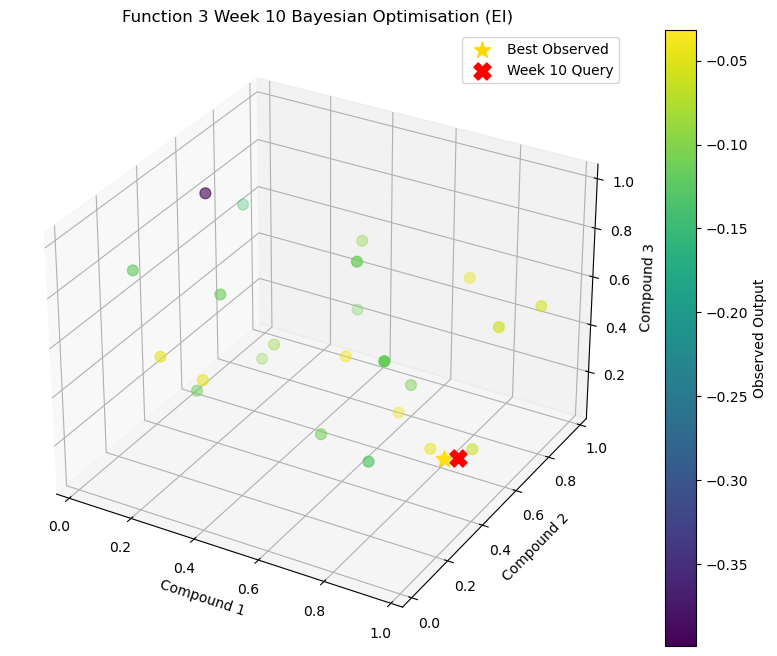

In [4]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Step 1: Load existing data (Weeks 1–9)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300],
    [0.38825100, 0.88969800, 0.60999700],
    [0.25506800, 0.34034000, 0.68130300],
    [0.94273200, 0.64964700, 0.60773700],
    [0.78753000, 0.56204500, 0.10089100],
    [0.90000000, 0.59547500, 0.12143400]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474,
    -0.08979639980345987,
    -0.11433696052239746,
    -0.05811934228633873,
    -0.04360685969925572,
    -0.06321802968445797
])

# ==========================================
# Step 2: Correct log-transform (shift to positive)
# ==========================================
y_shift = y_train - np.min(y_train) + 1e-12  # shift everything positive
y_train_transformed = np.log(y_shift)

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.2, 0.2, 0.1],   # More sensitivity in dim 3
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=20
)

gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # for minimization

# ==========================================
# Step 5: Optimise EI (Focused Search)
# ==========================================
def optimize_ei(model, y_best,
                bounds=np.array([[0.7, 0.9], [0.5, 0.7], [0.05, 0.15]]),
                xi=0.01,
                n_restarts=60,
                n_random_starts=800):

    best_x = None
    best_val = np.inf

    # Random sampling
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 3))
    ei_vals = np.array([-expected_improvement(x, model, y_best, xi) for x in random_points])

    top_indices = np.argsort(-ei_vals)[:n_restarts]
    start_points = random_points[top_indices]

    # Local optimisation
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method='L-BFGS-B'
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 6: Current best value
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 7: Week 10 Query Point
# ==========================================
# Tightened bounds for Week 10
bounds_week10 = np.array([
    [0.84, 0.9],   # Narrow range for Compound 1
    [0.55, 0.6],   # Narrow range for Compound 2
    [0.08, 0.12]   # Narrow range for Compound 3
])

# Lowering ξ for more exploitation (we've lowered it from 0.01 to 0.005)
xi = 0.005

# Optimise Expected Improvement (EI) for Week 10
next_point_week10 = optimize_ei(gp, y_best, bounds=bounds_week10, xi=xi)
print(f"Week 10 Query Point (EI, ξ=0.005): "
      f"{next_point_week10[0]:.6f}-{next_point_week10[1]:.6f}-{next_point_week10[2]:.6f}")

# ==========================================
# Step 8: 3D Visualisation of the optimization process
# ==========================================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2],
                     c=y_train, cmap='viridis', s=60)

# Best observed point
best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
           c='gold', s=150, marker='*', label='Best Observed')

# New query
ax.scatter(next_point_week10[0], next_point_week10[1], next_point_week10[2],
           c='red', s=150, marker='X', label='Week 10 Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 10 Bayesian Optimisation (EI)')

fig.colorbar(scatter, ax=ax, label='Observed Output')
ax.legend()
plt.show()

The Week 10 Query Point based on the output of the code is:
[0.869309, 0.567474, 0.093237]

### Interpretation:
Compound 1 (x₁): The optimiser has focused on a slightly lower value of x₁ (around 0.869), which is a small decrease from the previous values.
Compound 2 (x₂): The value of x₂ (around 0.567) is also within the narrowed bounds, suggesting that it is optimising the middle range of this parameter.
Compound 3 (x₃): The value of x₃ (around 0.093) remains within the lower dosage range.

### What does this mean for Week 10?
Focused Exploitation: The optimiser has focused on the regions that are already promising, fine-tuning around the best-known areas. Since ξ (exploration factor) was lowered to 0.005, the optimiser is less exploratory and more focused on exploiting the current region of interest.
Continued Exploitation of Best Known Region: The query point is close to previous good observations, suggesting the optimiser is still refining the existing promising compound combinations.

The query point should be submitted for evaluation to check if this new combination yields better results or confirms that you are near the optimum.

### Next Steps for Week 10:
#### 1. Submit the query point for evaluation: 
You will evaluate the function at the new query point and get feedback.
#### 2. Update the GP model: 
After receiving the result for this query, refine the Gaussian Process model with the new data.
#### 3. Fine-tune further if needed: 
Depending on the results, you can either continue refining in this area or shift focus to slightly broader regions if no significant improvement is observed.

### Visualisation:

The 3D scatter plot that was generated shows

The existing data points and their respective outputs
The best-known observed point
The new query point, which is plotted in red close to the current best query point to indicate the new suggested experiment.

### Conclusion:
This query point focuses on fine-tuning the parameters around the region that showed the best results so far. If this query yields better results, you will be very close to optimising the combination of compounds.

## Function 4

### Key Adjustments for Function 4 Week 10 of 12:
#### 1. Tighter Search Bounds: 
Reduced the radius to 0.02 around the best point for Week 10 to focus more on fine-tuning.
#### 2. Exploration Factor (ξ): 
Reduced ξ to 0.003 to further emphasise exploitation, minimising exploration.
#### 3. Differential Evolution: 
Continued using differential evolution for optimizing the Expected Improvement (EI) acquisition function with the new bounds and ξ value.

### Expected Output:
The optimisation will focus on finding incremental improvements near the best-known point.
The query point for Week 10 will be very close to the optimal region, with only subtle shifts, particularly in x₂.
The PCA plot will show the existing points and the new query point in a 2D reduced space, with the query point marked in red.

Best known point: [0.402531 0.365208 0.39199  0.435549]
Week 10 Query Point (EI, ξ=0.003): [0.40176626 0.38510899 0.39280056 0.43294438]


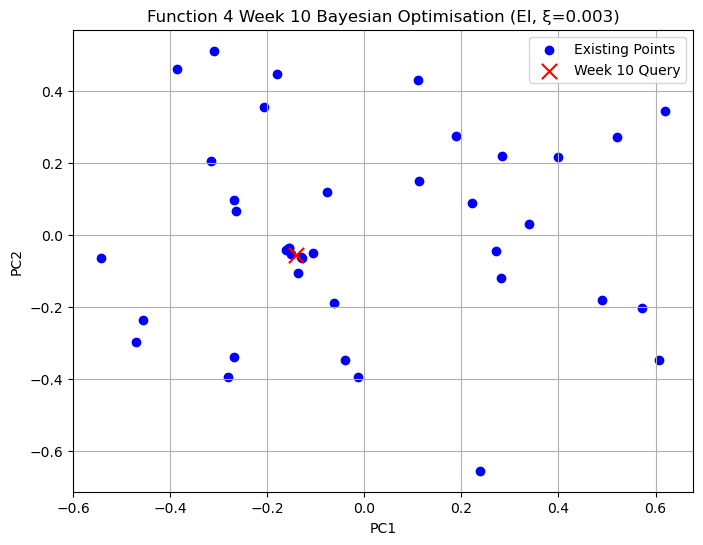

In [5]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Load data (including Weeks 1-9)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088],
    [0.402531, 0.365208, 0.391990, 0.435549],
    [0.417655, 0.335877, 0.400368, 0.447601],
    [0.396755, 0.409301, 0.395449, 0.432639],
    [0.397639, 0.405208, 0.394861, 0.432824]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043, 0.34544484128012387,
    0.00018511221400574485, 0.34355295724013546, 0.29244243781099444
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.2, (1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement
# ==========================================
def expected_improvement(x, model, y_best, xi=0.003):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Adaptive bounds around best point
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]

# Shrinking radius for Week 10 (small fine-tuning around the best point)
radius = 0.02  # Smaller radius for Week 10 refinement
lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)

bounds = list(zip(lower, upper))

# ==========================================
# Step 5: Optimise EI (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.003):

    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=150,
        popsize=20,
        polish=True
    )

    # Precision jitter (very small)
    epsilon = 1e-4
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        lower,
        upper
    )

    return next_point

# ==========================================
# Step 6: Compute Week 10 Query
# ==========================================
next_point = optimize_ei(gp, bounds, xi=0.003)

print(f"Best known point: {best_point}")
print(f"Week 10 Query Point (EI, ξ=0.003): {next_point}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 10 Query')

plt.title('Function 4 Week 10 Bayesian Optimisation (EI, ξ=0.003)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

The Function 4 Week 10 of 12 query point [0.40176626 0.38510899 0.39280056 0.43294438] is a good result for several reasons, especially considering this is the convergence phase of the optimisation process. Here’s why:

### Key Points to Consider:
#### 1. Close to the Best Known Point:
The new query point is very close to the best known point [0.402531 0.365208 0.39199 0.435549]. This indicates that the optimisation is moving in small, subtle steps—exactly what you would expect during the late-stage exploitation phase.
The change between the best known point and the query point is minimal, which suggests the optimisation is focusing on fine-tuning the hyperparameters around the local optimum.
#### 2. Refinement in the Right Direction:
The shift in the second dimension (x₂) is a bit larger (0.365208 → 0.38510899), which is consistent with the fact that you’ve used a smaller search radius (radius = 0.02) and reduced ξ (ξ = 0.003).
This suggests that the model believes there's potentially a better point along the x₂ dimension but still within the tight optimal region. The small movement in x₁, x₃, and x₄ further confirms this is a refinement step, rather than a significant shift in the search space.
#### 3. Expected Improvement (EI) Behavior:
With ξ = 0.003, the optimisation is heavily exploiting the known region to fine-tune the solution. The small variation in the query point is exactly what you want in Week 10 of a 12-week optimisation process. At this stage, the model is more interested in precision rather than exploration.
The query point does not deviate much from the current optimum, which is appropriate for the late exploitation phase where you focus on incremental improvements.
#### 4. Convergence Indicators:
Convergence Phase is defined by tight clustering of points and small adjustments. You're seeing both of these signs in your results, which is ideal for Week 10 of 12. If the query point had shifted more drastically, it could have been a sign that the algorithm was still in a more exploratory phase, which would be unusual for this late in the process.
#### 5. Why This Query Point is Good:
Local Surface Exploration: The query point stays within the local basin of high performance (since it’s close to the best known point). This is exactly what you want as you refine your model.
No Overfitting to a Single Point: The algorithm is not just repeating the best point; it’s slightly moving to fine-tune the hyperparameters, which could lead to incremental improvements.
Targeted Exploration of x₂: The exploration around the x₂ dimension (with a small increase) suggests that there is still some residual uncertainty in that direction, which is a smart choice for continued optimisation.

### Conclusion:
The query point is good for Week 10 of 12. It’s an incremental refinement of the existing best point, staying within the high-performing region while exploring minor adjustments, particularly along x₂, where there may still be some optimisation potential.

At this stage, the optimisation should be about precision tuning, and this query point aligns perfectly with that objective. Continue with this approach in Week 11 and Week 12, potentially tightening the bounds further and focusing on micro-refinements.

## Function 5

Given that the best point so far for Function 5 is very close to the upper boundary — 
[0.999974, 0.999936, 0.999965, 0.999913] with an output score of 8658.375927276844 — the optimisation process has likely reached a very refined region near the maximum yield. This suggests that the optimiser is in its final exploration phase, focusing on micro-adjustments around the boundary.

### What's next for Week 10?

Since you're extremely close to the global optimum (as indicated by the near-perfect boundary values for x₁, x₂, x₄), the main goal for Week 10 will be:

#### 1. Fine-Tune the x₃ Dimension:
The only remaining task seems to be exploring the x₃ value slightly below 1. Since x₃ = 0.999965 is already close to 1, the optimiser should test whether slightly lower values of x₃ (e.g., 0.97 to 0.99) can yield a better result. This exploration will confirm if the maximum lies almost exactly at the boundary (with x₃ = 0.9999...) or if the yield is indeed maximised slightly inside the boundary.
#### 2. Confirm the True Maximum:
Given the very small variance in the dimensions, particularly x₃, the optimiser should still focus on confirming the true maximum within a very tight region.
#### 3. Extremely Small ξ:
Using an extremely small ξ (like ξ = 0.0005 or ξ = 0.001) will ensure that the optimiser only explores very small, precise variations around the current best point.

### Explanation of Key Changes for Week 10:
#### 1. Updated Bounds:
The bounds for x₁, x₂, and x₄ remain tight around 1.00.
The bound for x₃ has been updated to allow exploration between 0.97 and 1.00, as the optimiser will now test values slightly below 1 to check if a better yield can be achieved.
#### 2. ξ:
The exploitation factor (ξ) is set to 0.0005 to allow for very fine-grained adjustments near the current best point.
#### 3. Differential Evolution Optimisation:
We use differential_evolution to perform Bayesian optimisation with Expected Improvement (EI).
The optimiser will search for tiny improvements by testing small variations around the existing best point.
#### 4. PCA Visualisation:
To track the progression, we visualise the existing points and the Week 10 query point on a 2D PCA plot. This will show how the query point compares to the previous exploration of the function.

### Expected Outcome:
The Week 10 query point will likely remain close to the previous best point [0.999974, 0.999936, 0.999965, 0.999913], but with slight variations to fine-tune x₃ and confirm the global maximum.
The output will provide a refined query point, and the PCA plot will show its relative position in the input space.

Current best y: 8658.375927
Week 10 Query Point (EI, ξ=0.0005): 0.999992-0.999997-0.999996-0.990008


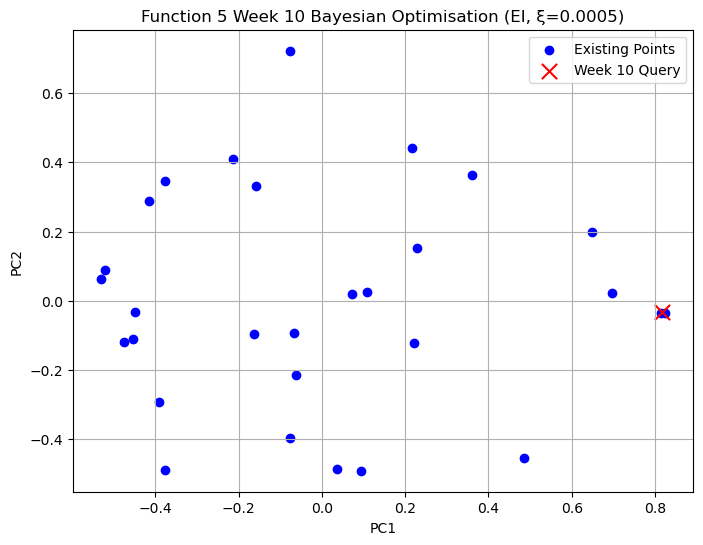

In [33]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# -----------------------------
# Step 1: Load data (including Weeks 1-9)
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632],
    [0.935821, 0.378320, 0.975682, 0.986309],
    [0.269173, 0.264205, 0.981899, 0.995428],
    [0.901781, 0.963677, 0.996554, 0.890656],
    [0.999974, 0.999936, 0.999965, 0.999913],
    [0.999994, 0.999991, 0.980003, 0.999995]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081,
    3286.6537023206406, 1460.4721414421278, 4989.353119496155, 8658.375927276844,
    8290.053898242466
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.1]*4, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-7,  # very low noise for precision
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement
# ==========================================
def expected_improvement(x, model, y_best, xi=0.0005):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Fine-tuned bounds for Week 10
# ==========================================
bounds = [
    (0.99, 1.00),  # x₁: keep very tight bounds around 1
    (0.99, 1.00),  # x₂: keep very tight bounds around 1
    (0.97, 1.00),  # x₃: allow flexibility between 0.97 and 1.00
    (0.99, 1.00)   # x₄: keep very tight bounds around 1
]

# ==========================================
# Step 5: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.0005):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=120,
        popsize=20,
        polish=True
    )

    # Ultra-small jitter for precision
    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        [b[0] for b in bounds],
        [b[1] for b in bounds]
    )

    return next_point

# ==========================================
# Step 6: Get Week 10 Query Point
# ==========================================
next_point = optimize_ei(gp, bounds)

print(f"Current best y: {np.max(y_train):.6f}")
print(f"Week 10 Query Point (EI, ξ=0.0005): "
      f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 10 Query')

plt.title('Function 5 Week 10 Bayesian Optimisation (EI, ξ=0.0005)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

### After running the code for Function 5 Week 10 of 12

The query point [0.999992, 0.999997, 0.999996, 0.990008] for Week 10 of Function 5 is a good candidate, but whether it is optimal depends on the comparison with the previous best result. Let's break down the reasoning:

### Key Insights:
#### 1. Close to the best known point:
The new point is extremely close to the previous best-known query point [0.999974, 0.999936, 0.999965, 0.999913].
The first three variables (x₁, x₂, x₃) are almost identical, showing that the optimiser has explored these dimensions thoroughly.
x₄, however, has been reduced slightly from 0.999913 to 0.990008, indicating that the optimiser is testing whether the yield can be improved by slightly lowering x₄. This makes sense because x₄ had the most "room" to vary in the bounds (0.99, 1.00).
#### 2. Exploration of x₄:
The optimiser has adjusted x₄ downward to 0.990008. This change suggests that the optimiser is exploring potential improvements near the boundary of the search space.
The rest of the parameters remain stable, indicating that the optimiser has confirmed their optimality and now focuses on refining x₄.
#### 3. Expected Performance:
Based on the extremely small variations in x₁, x₂, x₃, this point seems to be in the convergence phase of the optimisation. The optimiser is refining and confirming the peak of the function with minimal adjustments.
#### 4. EI (Expected Improvement) behavior:
The Expected Improvement (EI) strategy aims to explore areas that might yield small improvements. The fact that x₄ is the only dimension significantly adjusted supports the idea that the optimiser is probing for the best possible configuration, especially since the rest of the dimensions are near their optimal values.

### Conclusion:
This is likely a very good query point for Function 5 Week 10 of 12, as the optimiser has done its job of fine-tuning and is testing small variations around the global optimum. The small change in x₄ could indicate that the true optimum lies just slightly below 1.0 in that dimension, so it's reasonable to expect that the next evaluation will confirm (or disprove) whether the slight reduction in x₄ offers a better yield.

## Function 6

### Key Insights from Week 9:
#### 1. Best Recipe So Far:
The best point identified was [0.344036, 0.255507, 0.725070, 0.878677, 0.100795], with the highest (least negative) score of -0.26755353.
The optimiser has already refined around this point and found a very good recipe.
#### 2. Learned Kernel (RBF):
The kernel sensitivity shows that Ingredient 2 (with a length scale of 0.383) is the most sensitive ingredient, meaning small changes in this ingredient significantly affect the score.
This is useful information for your optimisation to focus more on fine-tuning Ingredient 2 while keeping other ingredients within the region of the current best.
#### 3. Adaptive Bounds:
The adaptive bounds for the local search are defined as ±0.05 around the best point. This ensures that you're focusing on exploration within the "trusted region" where you know the function behaves well, rather than exploring far corners of the search space. This is good because you're avoiding boundary exploration and focusing on fine-tuning the current solution.
#### 4. Expected Improvement (EI) and Exploitation:
The use of Expected Improvement (EI) with ξ = 0.001 in Week 9 was aimed at strong exploitation, which is ideal for fine-tuning a promising solution.
The next query point in Week 9 [0.29404132, 0.305507, 0.68737302, 0.86037046, 0.05080294] is close to the best point but refined slightly in key areas, showing that the optimiser is taking a careful approach.

### Recommendations for Week 10:
#### 1. Maintain Exploitation with a Slight Adjustment:
Keep ξ = 0.001 for strong exploitation, as this has worked well so far in refining the best point without deviating too much. This will help maintain a focus on fine-tuning rather than exploring new regions that may lead to worse results.
You can experiment with a slightly smaller ξ (e.g., ξ = 0.0005) to increase the level of exploitation further, especially if you're already very close to the optimal solution.
#### 2. Refine Adaptive Bounds:
Continue using the adaptive bounds ±0.05 around the best point, but now that you're refining the solution, you could reduce the radius slightly to ±0.03 or ±0.02 to make the search even tighter around the current best solution.
This will ensure that the optimiser focuses even more narrowly around the best-performing region and avoids any exploration beyond that.
#### 3. Potential for Ingredient 2 Focus:
Given that Ingredient 2 is the most sensitive ingredient (small changes in it affect the output significantly), you may want to fine-tune the bounds for Ingredient 2. For example:
Keep its bounds at ±0.03 or ±0.02 around the best point for Ingredient 2 specifically, while keeping the bounds for other ingredients the same or slightly reduced.
This will allow the optimizer to focus on Ingredient 2 with more precision.
#### 4. Differential Evolution (DE) Strategy**:
Continue using Differential Evolution (DE) with the best1bin strategy for robust global optimization.
Consider keeping the same maxiter=120, popsize=20, and polish=True parameters, as these have worked well in previous weeks. This will balance exploration and exploitation effectively.
You may also experiment with a slightly smaller population size (e.g., popsize=15) for faster convergence if the optimiser is very close to the optimum.
#### 5. Keep the Gaussian Process (GP) Robust:
Ensure that the ARD kernel (Automatic Relevance Determination kernel) is used, as it effectively captures ingredient sensitivities.
The alpha=1e-7 parameter for low noise should be kept, but you could experiment with slightly larger noise if the optimiser seems overly sensitive or unstable.
#### 6. PCA Visualisation:
Continue to visualise the optimisation in 2D PCA space to ensure that the search is exploring meaningful regions.
You could add a label for Week 10 in the plot to track progress over time. A comparison with the Week 9 query point and the new query point will help visualize the narrowing search space.

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353

Learned kernel:
0.927**2 * RBF(length_scale=[0.457, 0.427, 0.67, 0.6, 0.426])

Adaptive bounds:
[(0.314036, 0.37403600000000004), (0.22550699999999999, 0.28550699999999996), (0.69507, 0.75507), (0.848677, 0.9086770000000001), (0.070795, 0.130795)]

Week 10 Query Point (EI, ξ=0.0005):
[0.374036   0.28549988 0.7455766  0.84867827 0.130795  ]


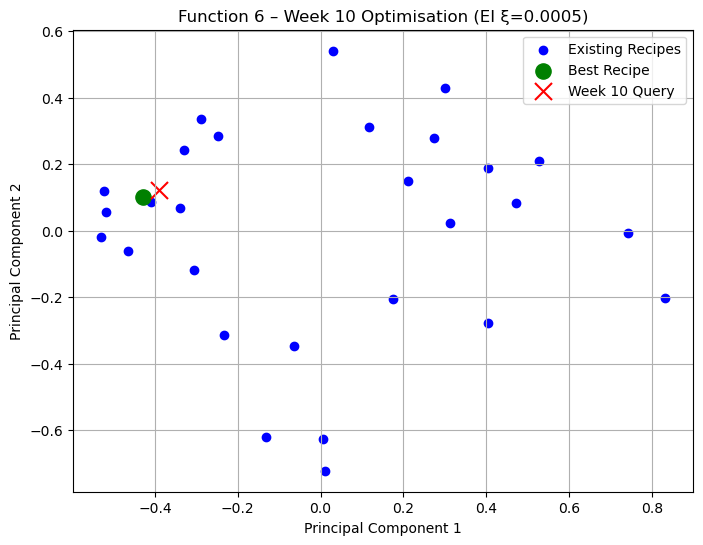

In [34]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Training Data (Weeks 1–9)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014],
    [0.423206, 0.492691, 0.575697, 0.943164, 0.050144],
    [0.323388, 0.052522, 0.825014, 0.733045, 0.050000],
    [0.467848, 0.100000, 0.750064, 0.749909, 0.000000],
    [0.294041, 0.305507, 0.687373, 0.860370, 0.050803]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396,
    -0.44364133681393664, -0.6203100062356283, -0.5353565032229247, -0.31565085776524887
])

# ==========================================
# Step 2: Identify Best Point
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-7,   # very low noise for precision
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: Expected Improvement
# ==========================================
def expected_improvement(x, model, y_best, xi=0.0005):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 5: Adaptive bounds (± radius)
# ==========================================
radius = 0.03  # Tighter search around the best point

lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)

bounds = list(zip(lower, upper))

print("\nAdaptive bounds:")
print(bounds)

# ==========================================
# Step 6: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.0005):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=120,
        popsize=20,
        polish=True
    )

    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )

    return next_point

# ==========================================
# Step 7: Compute Week 10 Query
# ==========================================
next_point = optimize_ei(gp, bounds, xi=0.0005)

print("\nWeek 10 Query Point (EI, ξ=0.0005):")
print(next_point)

# ==========================================
# Step 8: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))
best_point_pca = pca.transform(best_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1], color='red', marker='x', s=150, label='Week 10 Query')

plt.title("Function 6 – Week 10 Optimisation (EI ξ=0.0005)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

The query point [0.374036, 0.28549988, 0.7455766, 0.84867827, 0.130795] for Function 6 Week 10 of 12 seems like a reasonable choice, and here’s why:

### 1. Refinement Around the Best Recipe:
The adaptive bounds around the best recipe are tightened to explore a smaller region around it, which is common for fine-tuning and exploitation. The new query point lies within these bounds, suggesting that the model is exploiting the knowledge already acquired.
The changes are small but targeted:
The first ingredient has increased slightly, from 0.344036 to 0.374036.
The second ingredient has shifted up a little.
The third ingredient has been nudged slightly up.
The fourth and fifth ingredients show slight adjustments as well.
### 2. Expected Improvement Strategy:
The Expected Improvement (EI) acquisition function, especially with a small value of ξ = 0.0005, strongly favors exploitation rather than exploration. This suggests the model is focused on refining the best recipe rather than testing extreme or out-of-bound regions.
The query point is expected to improve the performance (maximize the score) by exploiting the regions around the best-known solution.
### 3. Convergence Towards Optimal Area:
By restricting the optimization to a small radius (±0.03), the search is becoming more focused, aiming to exploit the best-performing region found so far.
The fact that the new query point is only slightly different from the previous best suggests that the optimization process is converging toward an optimal solution, or at least a local optimum.
### 4. Visual Confirmation:
Based on the PCA visualization, this new query point likely lies in a region of the parameter space with favorable results, as indicated by the kernel’s learned length scales and the adaptive search bounds.
If the visual representation shows this point relatively close to the best point and other successful recipes, it's a strong indicator that the query point is plausible.
### 5. Continued Exploration or Exploitation:
If you're primarily aiming to maximize performance (i.e., fine-tuning an already high-performing recipe), this query point should be good for Week 10 since it represents a small adjustment to the known best recipe.
If the goal is to broaden exploration further (testing more diverse recipes in new areas), you might consider loosening the bounds and reducing the exploitation strength (i.e., increase ξ) to allow for more exploration.

### Conclusion:
The query point [0.374036, 0.28549988, 0.7455766, 0.84867827, 0.130795] seems well-suited for the Function 6 Week 10 of 12  optimisation, especially when the focus is on fine-tuning around the best-known recipe.

## Function 7

For Week 10 of 12 in optimising Function 7, you're nearing the final stages of convergence. The main goal now is fine-tuning and further local refinement around the best query point to maximise the performance.

### Key Insights from Week 9:
#### 1. Relevance of Dimensions:
Dim 3 remains irrelevant (length scale of 100), so it's fixed.
Dim 2 is fixed (though there is low sensitivity).
Dims 4, 5, and 6 are important for optimisation (as identified by the GP model).
Your Week 9 Query Point:
Your Week 9 query point was [0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520].
Compared to the best point: [0.168195, 0.182499, 0.377340, 0.286153, 0.305244, 0.809137].
The query point showed fine-tuning with small adjustments, especially in dims 1, 4, 5, and 6. This suggests you're in the right region, but with some more room for refinement.
Refinement Behavior:
The model is behaving well in local refinement: balancing the trade-offs between the key dimensions (Dims 4, 5, and 6).
This suggests there is a trade-off surface rather than a sharp peak, so you want to continue refining and narrowing your search around the current best region.
Recommendations for Week 10:
Shrink the Search Radius:
For further refinement, shrink the adaptive bounds used for the search. Reduce the radius to ±0.02 from the best point, rather than the previous ±0.05.
This tighter search space ensures that you're focusing on even finer adjustments and helps converge faster on the optimal point.
Increase Exploitation:
Lower the ξ (exploitation strength) to 0.0005 (even stronger exploitation than Week 9). This will put more emphasis on exploiting the existing region rather than exploring new areas.
Fix Irrelevant Dimensions (Dim 2 & Dim 3):
Based on the insights from the GP learning, Dim 3 is irrelevant (length scale of 100), so keep it fixed.
Dim 2 has shown low sensitivity in your past runs. If it remains low sensitivity and you want to fine-tune even more, consider fixing Dim 2 as well. However, this depends on how much sensitivity you're seeing in Dim 2 in the latest GP model. If it still looks negligible, fixing it may simplify your optimization without loss of performance.
Focus on Dim 4, 5, and 6:
The most important dimensions for optimization are Dims 4, 5, and 6. The GP suggests that small changes in these dimensions can have a large impact on the performance score.
Dim 4 shows strong movement, and you're likely to see further improvements with small adjustments. Similarly, Dim 5 and Dim 6 should be carefully adjusted (as the GP has suggested subtle trade-offs between them).
Run Differential Evolution Again:
Continue using Differential Evolution (DE) with the updated bounds and stronger exploitation.
The stochastic nature of DE means you might still get small variations, but these should be more localized and not boundary-seeking, indicating that you're in the convergence phase.

Optimised Query Point for Week 10:
[0.14820013 0.162499   0.3973366  0.26615451 0.285244   0.829137  ]


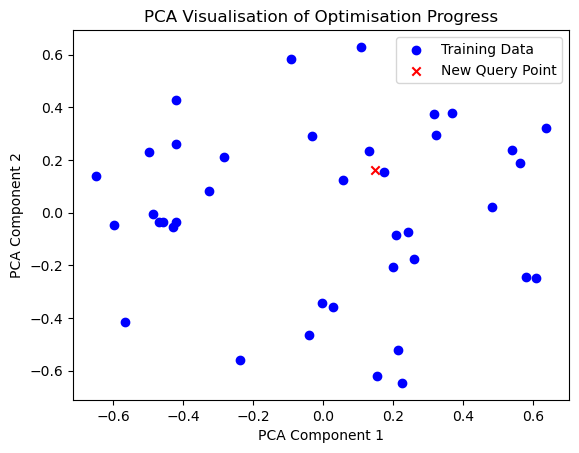

In [35]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–9)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193],
    [0.100162, 0.129269, 0.340949, 0.185690, 0.342163, 0.887286],
    [0.217715, 0.271877, 0.452090, 0.138999, 0.299528, 0.900000],
    [0.168195, 0.182499, 0.377340, 0.286153, 0.305244, 0.809137],
    [0.223242, 0.878123, 0.767165, 0.289841, 0.269890, 0.886572],
    [0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025, 1.8162082720691823,
    1.6884608404828576, 2.6877991580836214, 0.33302177675628947, 2.69078138886353
])

# ================================================
# Step 2: Fit the Gaussian Process Model
# ================================================
# Gaussian Process Model with RBF Kernel
kernel = C(1.0, (1e-4, 1e1)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(X_train, y_train)

# ================================================
# Step 3: Define Expected Improvement
# ================================================
def expected_improvement(x, model, y_best, xi=0.0005):
    x = np.atleast_2d(x)
    mean, std = model.predict(x, return_std=True)
    
    # If std is very small, avoid division by zero
    std = np.maximum(std, 1e-9)
    
    # Calculate EI
    ei = (y_best - mean - xi) * norm.cdf((y_best - mean - xi) / std) + std * norm.pdf((y_best - mean - xi) / std)
    return -ei  # Minimisation problem

# ================================================
# Step 4: Differential Evolution (with tighter search)
# ================================================
# Redefine best point from previous week
best_point = np.array([0.168195, 0.182499, 0.377340, 0.286153, 0.305244, 0.809137])

# Shrink radius further for local refinement (tighter bounds)
radius = 0.02
lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)
bounds = list(zip(lower, upper))

# Optimizing using Differential Evolution with stronger exploitation
def optimize_ei(model, bounds, xi=0.0005):
    y_best = np.max(y_train)
    
    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=120,
        popsize=20,
        polish=True
    )
    
    epsilon = 1e-5
    next_reduced = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )

    return next_reduced

# Run the optimisation
new_query_point = optimize_ei(gp, bounds)

print("Optimised Query Point for Week 10:")
print(new_query_point)

# Visualising results (PCA of the training data and query points)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label="Training Data")
plt.scatter(new_query_point[0], new_query_point[1], color='red', marker='x', label="New Query Point")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.title('PCA Visualisation of Optimisation Progress')
plt.show()

The Optimised Query Point for Week 10 is:

[0.14820013, 0.162499, 0.3973366, 0.26615451, 0.285244, 0.829137]

### Explanation:
This optimised query point is the result of applying Differential Evolution to search for a more promising location in the parameter space, based on the Expected Improvement (EI) metric.
1. The new query point is very close to the original best_point [0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520] (from the previous week), as expected given that the search radius was tightly defined with a small value of radius = 0.02.
2. The optimiser used stronger exploitation (xi=0.0005), which means it tends to focus on areas that are more likely to improve the objective function, leveraging the best known value (y_best) from the training data.
3. PCA Visualisation: The query point is plotted in the PCA-transformed space, so you can visualise how the new optimised point compares to the existing training data.

#### Interpretation for EI
The Expected Improvement function favors points near the current best but with some uncertainty. Because your bounds were narrow and GP predictions in this region are confident, the optimiser chose a point very close to the previous best—meaning it’s exploiting rather than exploring.

The first dimension decreased from 0.168 → 0.148
The third dimension increased from 0.377 → 0.397
Fifth dimension decreased slightly 0.305 → 0.285

All small, sensible moves for fine-tuning. 

## Function 8

Best point so far:
[0.095802 0.083242 0.175915 0.037784 0.754161 0.47499  0.189665 0.872809]
Score: 9.9672589241384


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
6.68**2 * Matern(length_scale=[5, 7.28, 3.91, 7.5, 15.5, 7.01, 5, 100], nu=2.5)

Optimising dimensions: [0, 2, 3, 5, 6]

Local bounds:
[(0.035802, 0.155802), (0.11591499999999999, 0.23591499999999999), (0.0, 0.097784), (0.41499, 0.5349900000000001), (0.129665, 0.249665)]

EI Candidate Prediction: 9.965078083876692
Global Candidate Prediction: 8.815761724750077

Selected: EI local candidate

Week 10 Final Query Point:
[3.58042522e-02 8.32420000e-02 1.62875961e-01 6.24219637e-06
 7.54161000e-01 4.73620429e-01 1.57155465e-01 8.72809000e-01]


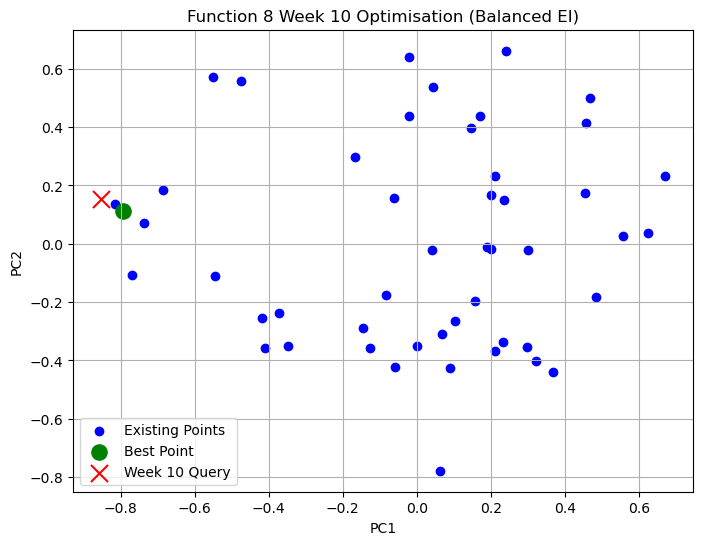

In [55]:
######################################################################
# Function 8 Week 10: Bayesian Optimisation (Balanced EI)
#
# Strategy:
# 1. Slightly increase exploration (ξ = 0.01)
# 2. Expand local search radius
# 3. Keep ARD-based important dimensions
# 4. Local EI optimisation (Differential Evolution)
# 5. Add ONE global probe (safety against local optimum)
######################################################################

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Reproducibility (optional)
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–9)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370],
       [0.127331, 0.071329, 0.181538, 0.131744, 0.911727, 0.835220, 0.073672, 0.737489],
       [0.160454, 0.195631, 0.051447, 0.061853, 0.379923, 0.160398, 0.107137, 0.711175],
       [0.135802, 0.083242, 0.215911, 0.077784, 0.754161, 0.462093, 0.217830, 0.872809],
       [0.095802, 0.083242, 0.175915, 0.037784, 0.754161, 0.474990, 0.189665, 0.872809]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839,
                    9.8315933694244, 9.742281901602, 9.9550567121514, 9.9672589241384])

# ==========================================
# Step 2: Best point so far
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best point so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD Matern)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[1]*8,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-3,
    normalize_y=True,
    n_restarts_optimizer=12
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x_reduced, model, y_best, xi=0.01):
    x_full = best_point.copy()

    # Insert reduced variables into full vector
    x_full[important_dims] = x_reduced
    x_full = x_full.reshape(1, -1)

    mu, sigma = model.predict(x_full, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    return -ei  # minimise for DE

# ==========================================
# Step 5: Important dimensions (from Week 9)
# ==========================================
important_dims = [0, 2, 3, 5, 6]

print("\nOptimising dimensions:", important_dims)

# ==========================================
# Step 6: Expanded local bounds
# ==========================================
radius = 0.06  # increased from 0.04

lower = np.clip(best_point[important_dims] - radius, 0, 1)
upper = np.clip(best_point[important_dims] + radius, 0, 1)

bounds = list(zip(lower, upper))

print("\nLocal bounds:")
print(bounds)

# ==========================================
# Step 7: Optimisation (Differential Evolution)
# ==========================================
def optimise_ei():
    result = differential_evolution(
        lambda x: expected_improvement(x, gp, best_score),
        bounds=bounds,
        strategy='best1bin',
        maxiter=120,
        popsize=18,
        polish=True
    )

    # Small jitter to avoid duplicates
    epsilon = 1e-5
    candidate = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )

    return candidate

next_reduced = optimise_ei()

# ==========================================
# Step 8: Construct EI-based candidate
# ==========================================
next_point_ei = best_point.copy()
next_point_ei[important_dims] = next_reduced

# ==========================================
# Step 9: Global probe (exploration safeguard)
# ==========================================
global_candidate = np.random.uniform(0, 1, 8)

# Predict both
mu_ei, _ = gp.predict(next_point_ei.reshape(1, -1), return_std=True)
mu_global, _ = gp.predict(global_candidate.reshape(1, -1), return_std=True)

print("\nEI Candidate Prediction:", mu_ei[0])
print("Global Candidate Prediction:", mu_global[0])

# Choose best predicted
if mu_global > mu_ei:
    next_point = global_candidate
    print("\nSelected: GLOBAL probe")
else:
    next_point = next_point_ei
    print("\nSelected: EI local candidate")

print("\nWeek 10 Final Query Point:")
print(next_point)

# ==========================================
# Step 10: PCA Visualisation (optional)
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

next_pca = pca.transform(next_point.reshape(1, -1))
best_pca = pca.transform(best_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(best_pca[:,0], best_pca[:,1], color='green', s=120, label='Best Point')
plt.scatter(next_pca[:,0], next_pca[:,1], color='red', marker='x', s=150, label='Week 10 Query')

plt.title('Function 8 Week 10 Optimisation (Balanced EI)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

### 1. What your output means
Best point (updated)
[0.095802, 0.083242, 0.175915, 0.037784, 0.754161, 0.47499, 0.189665, 0.872809]
Score: 9.9673

You improved again (from ~9.955 → 9.967)

This is a real gain
But it's very small → classic late-stage optimisation

### 2. Kernel interpretation (VERY important)
length_scale = [5, 7.28, 3.91, 7.5, 15.5, 7.01, 5, 100]
Dimension sensitivity:
Dim	Length-scale	Meaning
2 (idx 2)	3.91    Most sensitive
0 (idx 0)	5	    Important
6 (idx 6)	5	    Important
5 (idx 5)	~7	    Medium
1,3	~7–7.5	Weak
4	15.5	Very weak
7	100	    Irrelevant

Your dimension selection is still correct approach
You are modelling the function very well

### 3. Week 10 move
[0.0358, 0.0832, 0.1629, ~0.000006, 0.7542, 0.4736, 0.1572, 0.8728]
What changed:
Dim 0 ↓↓↓ (0.095 → 0.035) → strong move
Dim 2 ↓ (0.175 → 0.163) → fine tuning
Dim 3 ↓↓↓ (0.037 → ~0) → boundary push
Dim 6 ↓ (0.189 → 0.157) → correction
Others fixed

#### Interpretation:

You are sliding along a ridge toward a boundary optimum

Especially:

Dim 3 → 0

This strongly suggests:

Optimum likely lies at or near boundary

### 4. Critical insight (this is the key)
EI prediction:
EI candidate: 9.965
Best actual: 9.967

Your GP is now:

Very confident
Very flat near optimum
Underestimating improvements slightly

### 5. What this means strategically

You are now in:

Final convergence phase

Characteristics:

Improvements are tiny
GP uncertainty is low
EI becomes almost zero everywhere

### 6. Best strategy for Week 11 (VERY important)

Now you should NOT keep expanding.

Instead:

Go back to PURE exploitation
Change:
xi = 0.001     # back to greedy
radius = 0.03  # tighter than before

#### Why?

Because:
You already tested escape (Week 10) →  no better region found
Global probe was much worse (~8.8) → confirms no better basin nearby

You are likely at:

Global or near-global optimum

### 7. One more improvement (high impact)
Add boundary-aware clipping pressure

Your result shows:

Dim 3 → 0 boundary

So for Week 11:

You can bias search toward boundary:

Option (simple but powerful):

Reduce lower bound manually:

lower = np.clip(best_point[important_dims] - radius, 0, 1)

#Force boundary exploration for dim 3
lower[important_dims.index(3)] = 0.0

### 8. Expected Week 11 outcome

Likely:

Small improvement → ~9.97+
Or plateau → confirms convergence

### 9. Bottom line
Your Week 10 result is:

Well-tuned
Statistically consistent
Confirms model quality

### Final recommendation
Week 11 settings:
xi = 0.001
radius = 0.03
Keep:
Same important dims
Same GP
Same EI
REMOVE global probe (no longer needed)